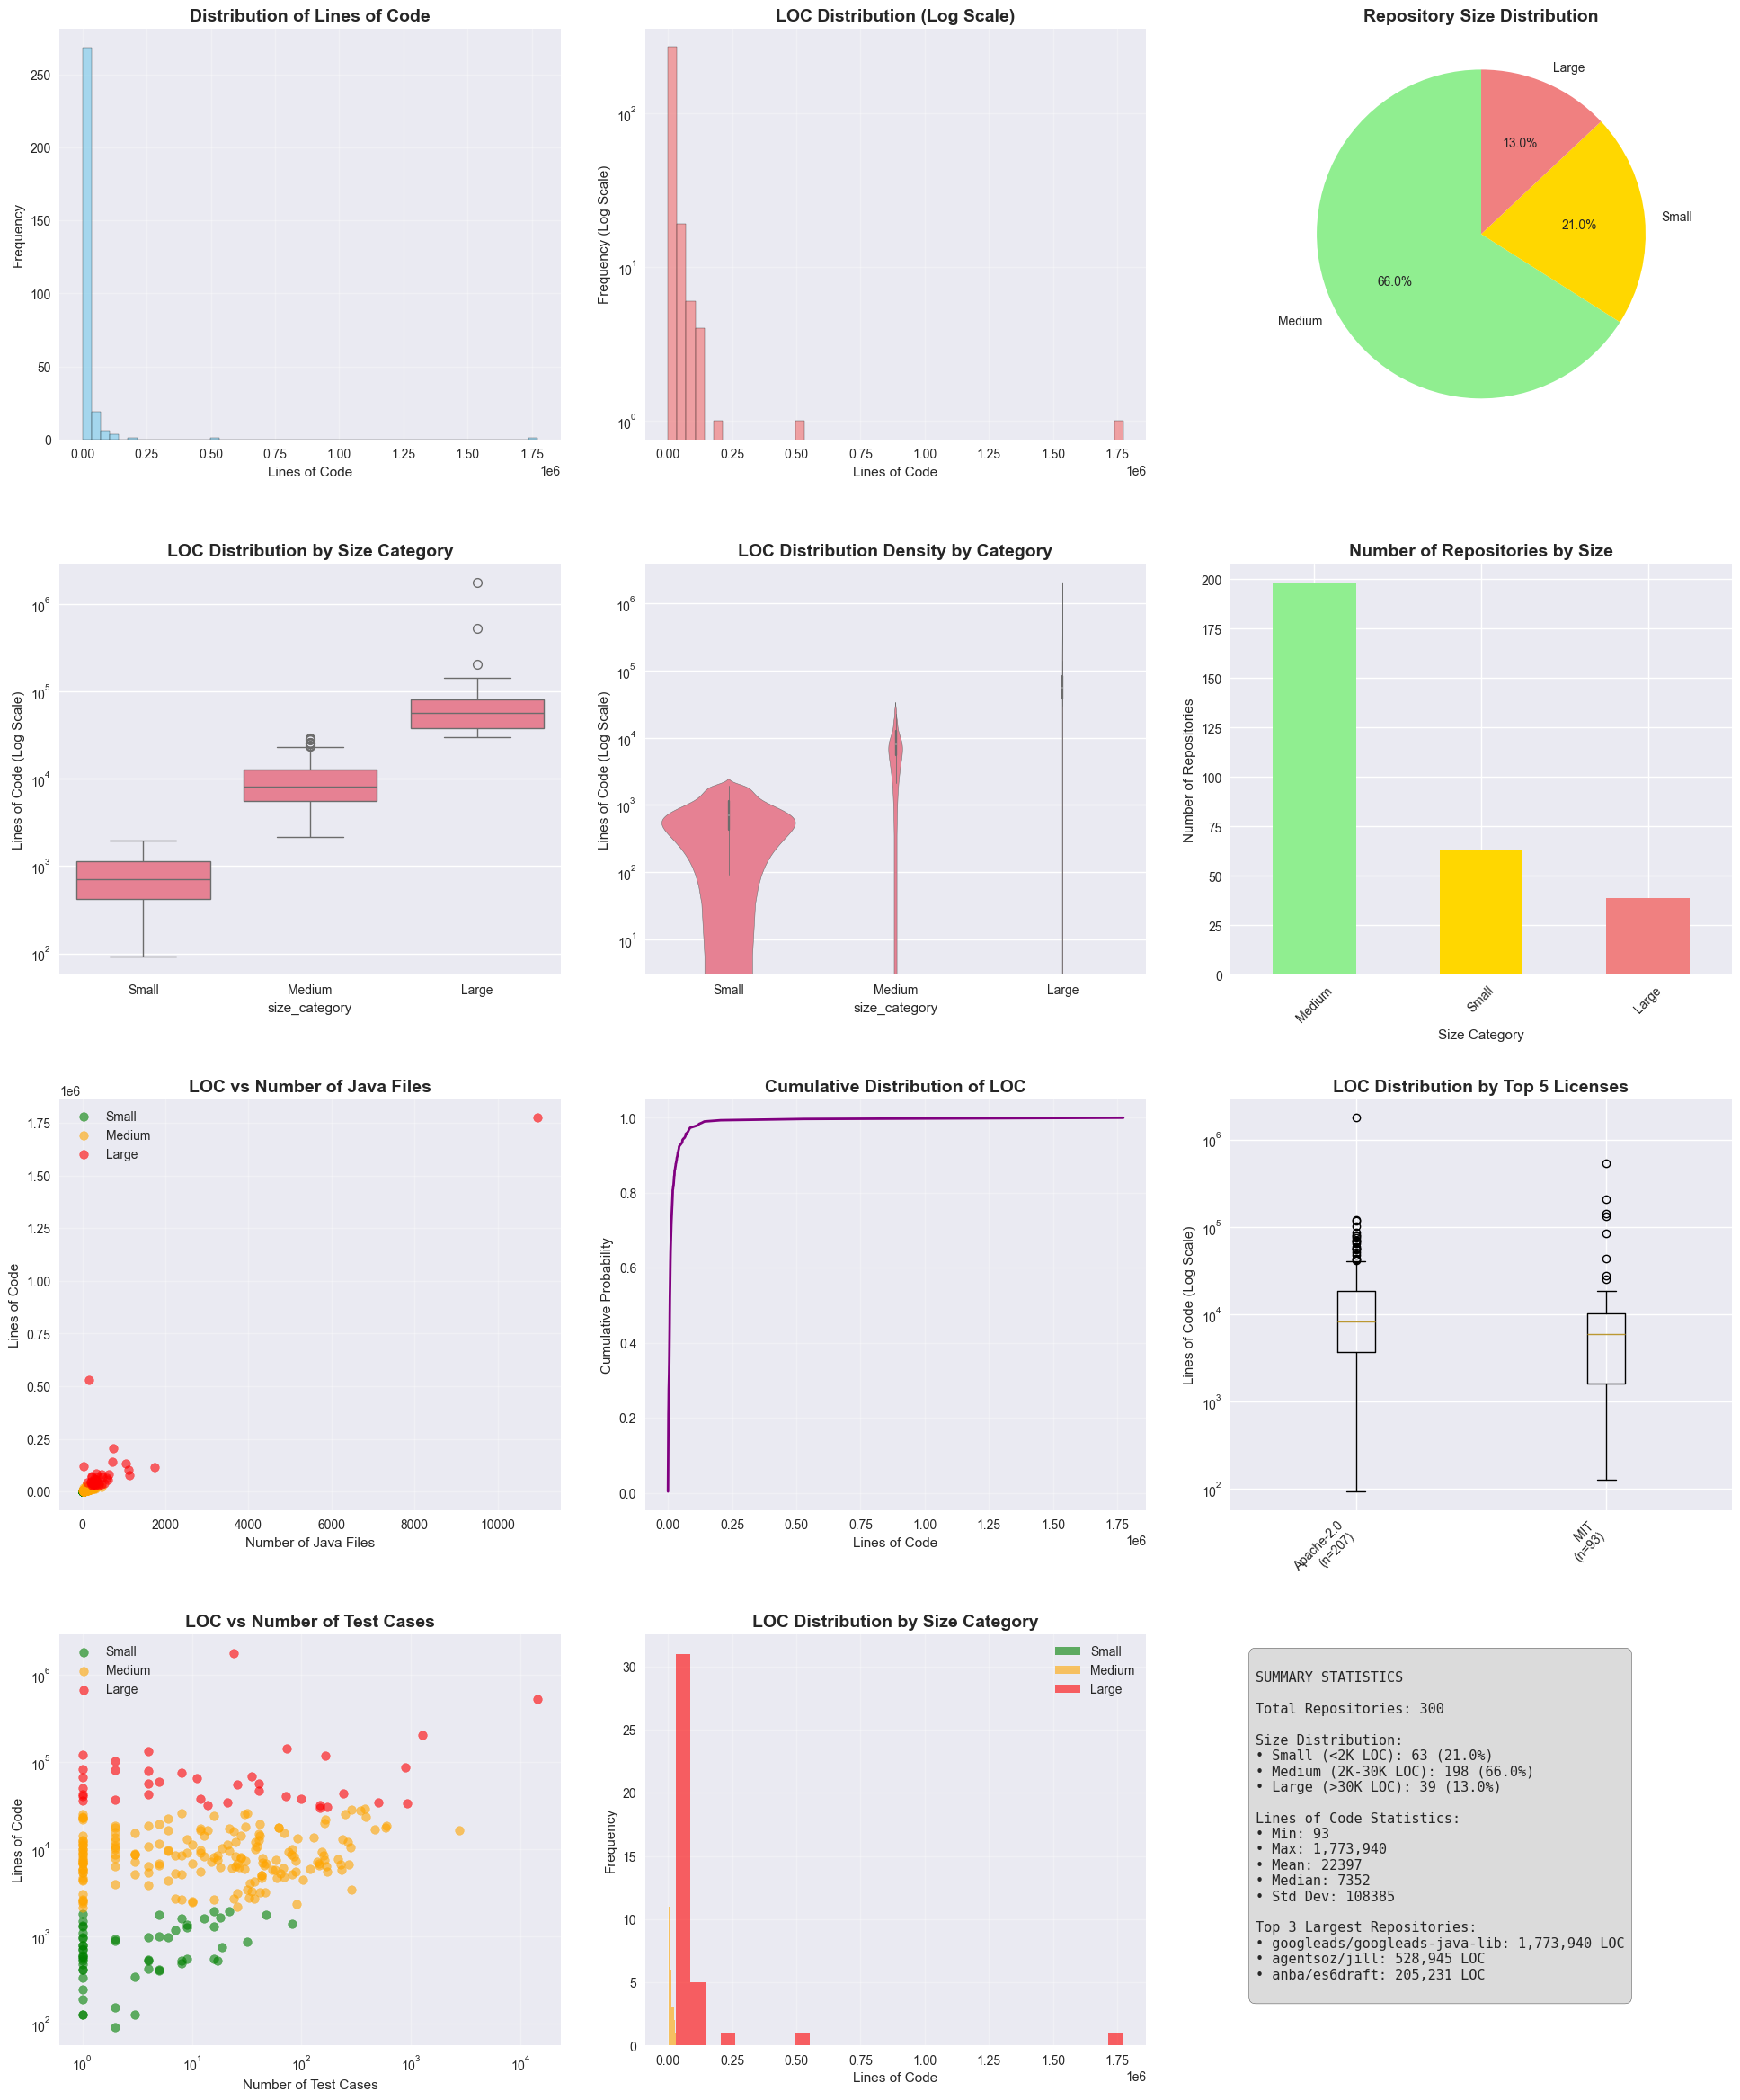

DETAILED REPOSITORY ANALYSIS

Dataset Overview:
Total repositories analyzed: 300
Date range covered: Various commits

Lines of Code Statistics:
Mean LOC: 22397
Median LOC: 7352
Standard Deviation: 108385
25th Percentile: 2690
75th Percentile: 15579
99th Percentile: 142398

Size Category Breakdown:

Small Repositories:
  Count: 63
  Average LOC: 811
  Median LOC: 710
  LOC Range: 93 - 1952
  Avg Java Files: 15

Medium Repositories:
  Count: 198
  Average LOC: 9890
  Median LOC: 8067
  LOC Range: 2149 - 29228
  Avg Java Files: 109

Large Repositories:
  Count: 39
  Average LOC: 120765
  Median LOC: 56258
  LOC Range: 30045 - 1773940
  Avg Java Files: 715

License Distribution:
  Apache-2.0: 207 (69.0%)
  MIT: 93 (31.0%)

Top 10 Largest Repositories:
  googleads/googleads-java-lib: 1,773,940 LOC, 10970 Java files, Apache-2.0
  agentsoz/jill: 528,945 LOC, 168 Java files, MIT
  anba/es6draft: 205,231 LOC, 751 Java files, MIT
  rcsb/ciftools-java: 141,763 LOC, 713 Java files, MIT
  sco0ter/b

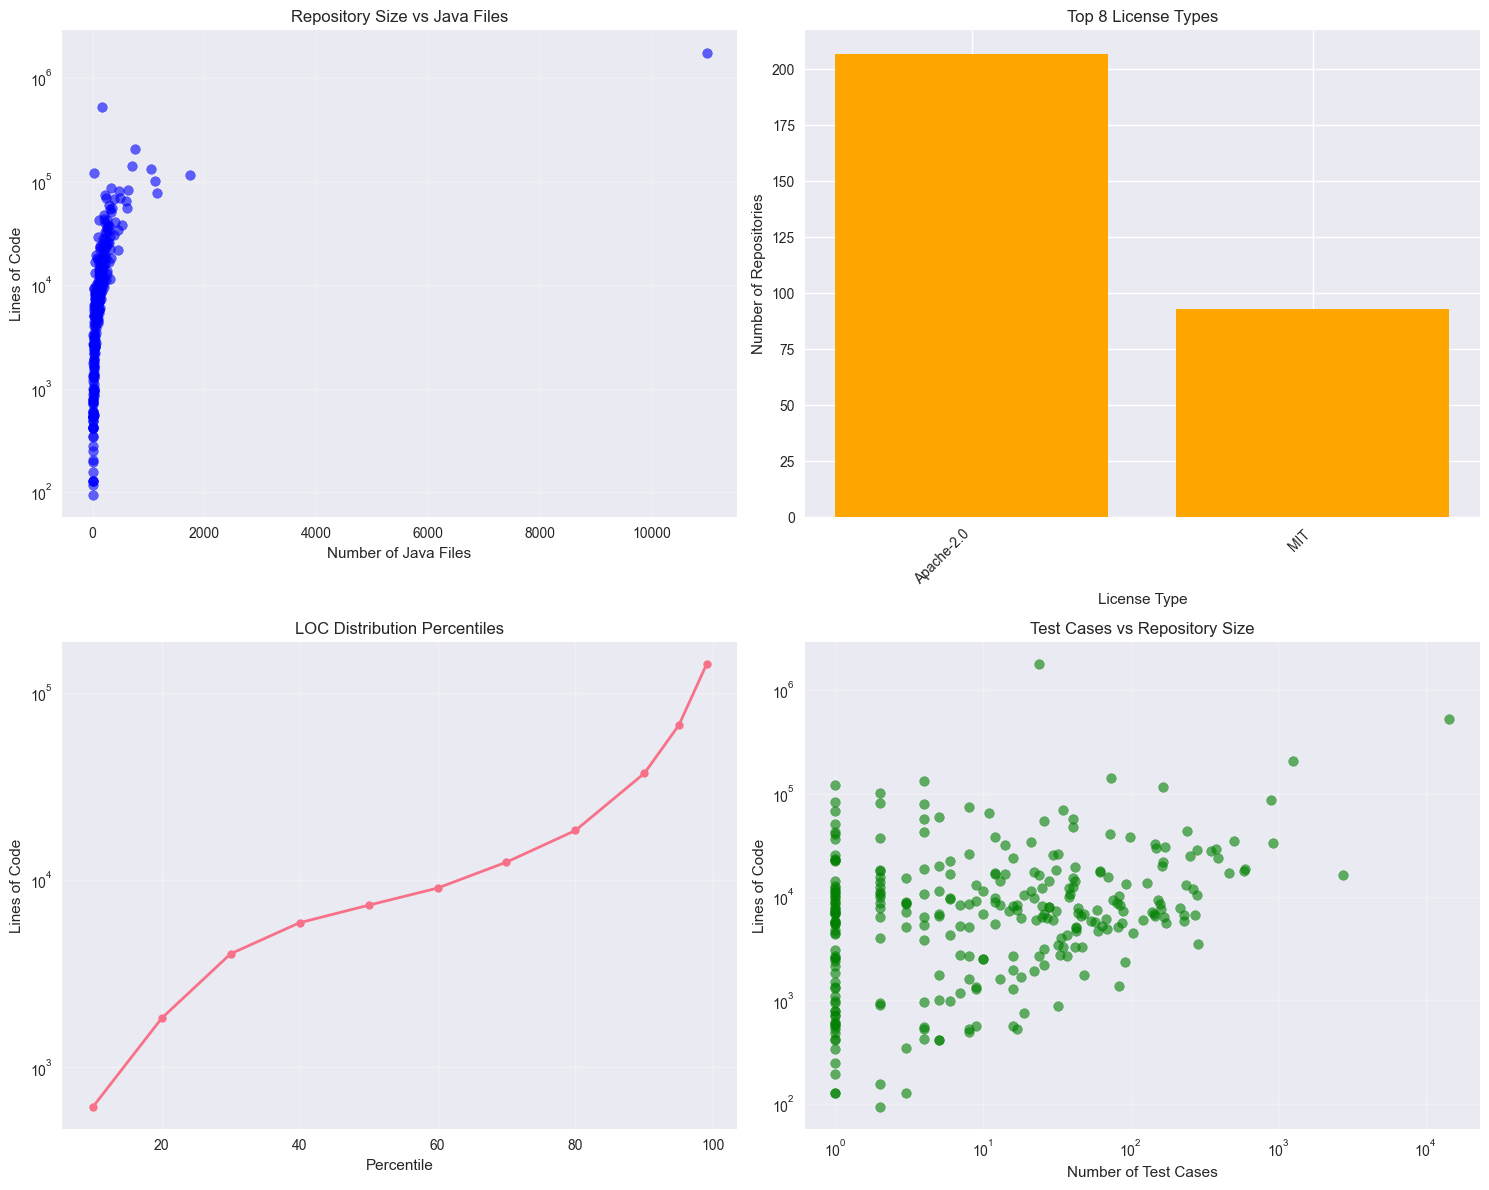


ANALYSIS COMPLETE
Generated visualizations:
1. repository_analysis.png - Main comprehensive analysis
2. additional_analysis.png - Supplementary analysis


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('selected.csv')

# Clean the data - remove any negative test cases and handle outliers
df = df[df['num_test_cases'] >= -2]  # Keep valid data including -1, -2 values

# Define size categories based on lines of code
def categorize_size(loc):
    if loc < 2000:
        return 'Small'
    elif loc <= 30000:
        return 'Medium' 
    else:
        return 'Large'

# Apply categorization
df['size_category'] = df['num_loc'].apply(categorize_size)

# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 24))

# 1. Histogram of LOC Distribution
plt.subplot(4, 3, 1)
plt.hist(df['num_loc'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Lines of Code', fontsize=14, fontweight='bold')
plt.xlabel('Lines of Code')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# 2. Log-scale Histogram
plt.subplot(4, 3, 2)
plt.hist(df['num_loc'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
plt.yscale('log')
plt.title('LOC Distribution (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Lines of Code')
plt.ylabel('Frequency (Log Scale)')
plt.grid(True, alpha=0.3)

# 3. Size Category Pie Chart
plt.subplot(4, 3, 3)
size_counts = df['size_category'].value_counts()
colors = ['lightgreen', 'gold', 'lightcoral']
plt.pie(size_counts.values, labels=size_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Repository Size Distribution', fontsize=14, fontweight='bold')

# 4. Box Plot of LOC by Size Category
plt.subplot(4, 3, 4)
sns.boxplot(data=df, x='size_category', y='num_loc', 
           order=['Small', 'Medium', 'Large'])
plt.title('LOC Distribution by Size Category', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.ylabel('Lines of Code (Log Scale)')

# 5. Violin Plot
plt.subplot(4, 3, 5)
sns.violinplot(data=df, x='size_category', y='num_loc',
              order=['Small', 'Medium', 'Large'])
plt.title('LOC Distribution Density by Category', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.ylabel('Lines of Code (Log Scale)')

# 6. Bar Chart of Size Categories
plt.subplot(4, 3, 6)
size_counts.plot(kind='bar', color=['lightgreen', 'gold', 'lightcoral'])
plt.title('Number of Repositories by Size', fontsize=14, fontweight='bold')
plt.xlabel('Size Category')
plt.ylabel('Number of Repositories')
plt.xticks(rotation=45)

# 7. Scatter Plot: LOC vs Java Files
plt.subplot(4, 3, 7)
colors_map = {'Small': 'green', 'Medium': 'orange', 'Large': 'red'}
for category in ['Small', 'Medium', 'Large']:
    mask = df['size_category'] == category
    plt.scatter(df[mask]['num_java_files'], df[mask]['num_loc'], 
               c=colors_map[category], alpha=0.6, label=category)
plt.xlabel('Number of Java Files')
plt.ylabel('Lines of Code')
plt.title('LOC vs Number of Java Files', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 8. Cumulative Distribution
plt.subplot(4, 3, 8)
sorted_loc = np.sort(df['num_loc'])
cumulative = np.arange(1, len(sorted_loc) + 1) / len(sorted_loc)
plt.plot(sorted_loc, cumulative, linewidth=2, color='purple')
plt.title('Cumulative Distribution of LOC', fontsize=14, fontweight='bold')
plt.xlabel('Lines of Code')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)

# 9. LOC Distribution by License Type
plt.subplot(4, 3, 9)
top_licenses = df['license'].value_counts().head(5)
license_loc_data = []
license_names = []
for license_name in top_licenses.index:
    license_data = df[df['license'] == license_name]['num_loc']
    license_loc_data.append(license_data)
    license_names.append(f"{license_name}\n(n={len(license_data)})")

plt.boxplot(license_loc_data, labels=license_names)
plt.title('LOC Distribution by Top 5 Licenses', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.ylabel('Lines of Code (Log Scale)')
plt.xticks(rotation=45, ha='right')

# 10. Scatter Plot: LOC vs Test Cases
plt.subplot(4, 3, 10)
# Filter out negative test cases for this plot
valid_tests = df[df['num_test_cases'] >= 0]
for category in ['Small', 'Medium', 'Large']:
    mask = valid_tests['size_category'] == category
    plt.scatter(valid_tests[mask]['num_test_cases'], valid_tests[mask]['num_loc'], 
               c=colors_map[category], alpha=0.6, label=category)
plt.xlabel('Number of Test Cases')
plt.ylabel('Lines of Code')
plt.title('LOC vs Number of Test Cases', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# 11. Histogram with Size Category Overlay
plt.subplot(4, 3, 11)
for category in ['Small', 'Medium', 'Large']:
    data = df[df['size_category'] == category]['num_loc']
    plt.hist(data, alpha=0.6, label=category, bins=30, 
             color=colors_map[category])
plt.title('LOC Distribution by Size Category', fontsize=14, fontweight='bold')
plt.xlabel('Lines of Code')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# 12. Summary Statistics Table as Text
plt.subplot(4, 3, 12)
plt.axis('off')
stats_text = f"""
SUMMARY STATISTICS

Total Repositories: {len(df)}

Size Distribution:
• Small (<2K LOC): {len(df[df['size_category'] == 'Small'])} ({len(df[df['size_category'] == 'Small'])/len(df)*100:.1f}%)
• Medium (2K-30K LOC): {len(df[df['size_category'] == 'Medium'])} ({len(df[df['size_category'] == 'Medium'])/len(df)*100:.1f}%)
• Large (>30K LOC): {len(df[df['size_category'] == 'Large'])} ({len(df[df['size_category'] == 'Large'])/len(df)*100:.1f}%)

Lines of Code Statistics:
• Min: {df['num_loc'].min():,}
• Max: {df['num_loc'].max():,}
• Mean: {df['num_loc'].mean():.0f}
• Median: {df['num_loc'].median():.0f}
• Std Dev: {df['num_loc'].std():.0f}

Top 3 Largest Repositories:
"""

# Add top 3 largest repos
largest_repos = df.nlargest(3, 'num_loc')[['repo', 'num_loc']]
for idx, row in largest_repos.iterrows():
    stats_text += f"• {row['repo']}: {row['num_loc']:,} LOC\n"

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.tight_layout(pad=3.0)
plt.savefig('repository_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional detailed analysis
print("=" * 80)
print("DETAILED REPOSITORY ANALYSIS")
print("=" * 80)

print(f"\nDataset Overview:")
print(f"Total repositories analyzed: {len(df)}")
print(f"Date range covered: Various commits")

print(f"\nLines of Code Statistics:")
print(f"Mean LOC: {df['num_loc'].mean():.0f}")
print(f"Median LOC: {df['num_loc'].median():.0f}")
print(f"Standard Deviation: {df['num_loc'].std():.0f}")
print(f"25th Percentile: {df['num_loc'].quantile(0.25):.0f}")
print(f"75th Percentile: {df['num_loc'].quantile(0.75):.0f}")
print(f"99th Percentile: {df['num_loc'].quantile(0.99):.0f}")

print(f"\nSize Category Breakdown:")
size_analysis = df.groupby('size_category').agg({
    'num_loc': ['count', 'mean', 'median', 'min', 'max'],
    'num_java_files': 'mean',
    'num_test_cases': 'mean'
}).round(0)

for category in ['Small', 'Medium', 'Large']:
    if category in size_analysis.index:
        print(f"\n{category} Repositories:")
        print(f"  Count: {size_analysis.loc[category, ('num_loc', 'count')]}")
        print(f"  Average LOC: {size_analysis.loc[category, ('num_loc', 'mean')]:.0f}")
        print(f"  Median LOC: {size_analysis.loc[category, ('num_loc', 'median')]:.0f}")
        print(f"  LOC Range: {size_analysis.loc[category, ('num_loc', 'min')]:.0f} - {size_analysis.loc[category, ('num_loc', 'max')]:.0f}")
        print(f"  Avg Java Files: {size_analysis.loc[category, ('num_java_files', 'mean')]:.0f}")

print(f"\nLicense Distribution:")
license_counts = df['license'].value_counts()
for license_name, count in license_counts.head(10).items():
    percentage = (count / len(df)) * 100
    print(f"  {license_name}: {count} ({percentage:.1f}%)")

print(f"\nTop 10 Largest Repositories:")
largest = df.nlargest(10, 'num_loc')[['repo', 'num_loc', 'num_java_files', 'license']]
for idx, row in largest.iterrows():
    print(f"  {row['repo']}: {row['num_loc']:,} LOC, {row['num_java_files']} Java files, {row['license']}")

print(f"\nTop 10 Smallest Repositories:")
smallest = df.nsmallest(10, 'num_loc')[['repo', 'num_loc', 'num_java_files', 'license']]
for idx, row in smallest.iterrows():
    print(f"  {row['repo']}: {row['num_loc']:,} LOC, {row['num_java_files']} Java files, {row['license']}")

# Create a second figure for additional analysis
fig2, axes = plt.subplots(2, 2, figsize=(15, 12))

# Repository size vs number of Java files
axes[0, 0].scatter(df['num_java_files'], df['num_loc'], alpha=0.6, color='blue')
axes[0, 0].set_xlabel('Number of Java Files')
axes[0, 0].set_ylabel('Lines of Code')
axes[0, 0].set_title('Repository Size vs Java Files')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# License distribution (top 8)
top_8_licenses = df['license'].value_counts().head(8)
axes[0, 1].bar(range(len(top_8_licenses)), top_8_licenses.values, color='orange')
axes[0, 1].set_title('Top 8 License Types')
axes[0, 1].set_xlabel('License Type')
axes[0, 1].set_ylabel('Number of Repositories')
axes[0, 1].set_xticks(range(len(top_8_licenses)))
axes[0, 1].set_xticklabels(top_8_licenses.index, rotation=45, ha='right')

# LOC percentiles
percentiles = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99]
loc_percentiles = [df['num_loc'].quantile(p/100) for p in percentiles]
axes[1, 0].plot(percentiles, loc_percentiles, marker='o', linewidth=2, markersize=6)
axes[1, 0].set_xlabel('Percentile')
axes[1, 0].set_ylabel('Lines of Code')
axes[1, 0].set_title('LOC Distribution Percentiles')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# Test cases vs LOC (valid data only)
valid_test_data = df[df['num_test_cases'] >= 0]
axes[1, 1].scatter(valid_test_data['num_test_cases'], valid_test_data['num_loc'], 
                  alpha=0.6, color='green')
axes[1, 1].set_xlabel('Number of Test Cases')
axes[1, 1].set_ylabel('Lines of Code')
axes[1, 1].set_title('Test Cases vs Repository Size')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('additional_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n" + "="*80)
print("ANALYSIS COMPLETE")
print("Generated visualizations:")
print("1. repository_analysis.png - Main comprehensive analysis")
print("2. additional_analysis.png - Supplementary analysis")
print("="*80)
